This notebook has analysis, models after structural reinforcement using additional bolts with hypothesis of this might help capturing vibrations accurately without resonance or vibrations from setup base which inturn makes differentiating normal and unbalance state easy

In [1]:
import zipfile
import os

zip_path = "/content/Data_after_extra_screws_bolted.zip"
extract_path = "/content/extracted_data"

# Create directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List the extracted files to see what we're working with
extracted_files = os.listdir(extract_path)
print("Extracted files:", extracted_files)


Extracted files: ['Data_after_extra_screws_bolted']


### Phase 1, Step 1: Parsing the JSON structure
Here we load the `.jsonl` files into a pandas DataFrame. We also add a `machine_state` column derived from the filename so we keep track of the labels.

In [6]:
import os
import json
import pandas as pd
import glob

data_dir = os.path.join(extract_path, extracted_files[0])
jsonl_files = glob.glob(os.path.join(data_dir, "*.jsonl"))

all_data = []

for file_path in jsonl_files:
    # Extract the state from the filename based on convention: [Fault]_...
    filename = os.path.basename(file_path)
    state = filename.split('_')[0]

    with open(file_path, 'r') as f:
        for line in f:
            try:
                row_data = json.loads(line.strip())
                row_data['machine_state'] = state
                all_data.append(row_data)
            except json.JSONDecodeError:
                continue # Skip invalid lines if any

# Convert to a pandas DataFrame
df = pd.DataFrame(all_data)

print(f"Total rows loaded: {len(df)}")
display(df.head())

Total rows loaded: 12481


,time,axis,data,machine_state
0,1.776731e+09,Z,"[-817.228515625, -990.228515625, -820.22851562...",MechanicalLooseness
1,1.776731e+09,X,"[-172.96484375, -96.96484375, -32.96484375, 49...",MechanicalLooseness
2,1.776731e+09,Y,"[81.212890625, 36.212890625, -18.787109375, -9...",MechanicalLooseness
3,1.776731e+09,Z,"[-231.4716796875, -161.4716796875, -69.4716796...",MechanicalLooseness
4,1.776731e+09,X,"[-369.8779296875, -716.8779296875, -1013.87792...",MechanicalLooseness


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12481 entries, 0 to 12480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           12481 non-null  float64
 1   axis           12481 non-null  object 
 2   data           12481 non-null  object 
 3   machine_state  12481 non-null  object 
dtypes: float64(1), object(3)
memory usage: 390.2+ KB


In [8]:
unique_states = df['machine_state'].unique()
print("Unique machine states:", unique_states)

Unique machine states: ['MechanicalLooseness' 'Normal' 'Unbalance' 'Bearingfault' 'Misalignment']


### Phase 1, Step 2: Timestamp Matching (The Merge)
Grouping the rows by their exact time stamp to merge the isolated X, Y, and Z rows into a single multi-channel structure.

In [9]:
merged_records = []

# Process each machine state independently
for state, group_df in df.groupby('machine_state'):
    # Ensure chronological order
    group_df = group_df.sort_values('time')

    buffer = {}
    expected_axis = 'X'
    group_time = None

    for _, row in group_df.iterrows():
        axis = row['axis']
        wave = row['data']
        row_time = row['time']

        if axis == 'X' and expected_axis == 'X':
            buffer['X'] = wave
            group_time = row_time  # Use X's time for the triplet
            expected_axis = 'Y'

        elif axis == 'Y' and expected_axis == 'Y':
            buffer['Y'] = wave
            expected_axis = 'Z'

        elif axis == 'Z' and expected_axis == 'Z':
            buffer['Z'] = wave
            # Triplet complete!
            merged_records.append({
                'time': group_time,
                'machine_state': state,
                'X': buffer['X'],
                'Y': buffer['Y'],
                'Z': buffer['Z']
            })
            # Reset for the next sequence
            buffer = {}
            expected_axis = 'X'

        else:
            # Out-of-order or unexpected axis
            if axis == 'X':
                # Start a new group from this X
                buffer = {'X': wave}
                group_time = row_time
                expected_axis = 'Y'
            else:
                # Reset completely
                buffer = {}
                expected_axis = 'X'

# Convert the successful triplets back into a DataFrame
df_merged = pd.DataFrame(merged_records)

print(f"Total synchronized samples after merging: {len(df_merged)}")
display(df_merged.head())


Total synchronized samples after merging: 3767


,time,machine_state,X,Y,Z
0,1.776734e+09,Bearingfault,"[308.11328125, 273.11328125, 261.11328125, 286...","[-11.8427734375, -51.8427734375, 54.1572265625...","[-32.814453125, -45.814453125, 17.185546875, 2..."
1,1.776734e+09,Bearingfault,"[166.48046875, 249.48046875, 101.48046875, 225...","[273.0166015625, 262.0166015625, 238.016601562...","[-40.29296875, 21.70703125, -112.29296875, -13..."
2,1.776734e+09,Bearingfault,"[-61.7490234375, -197.7490234375, -125.7490234...","[-288.8369140625, -331.8369140625, -362.836914...","[55.91796875, 75.91796875, 188.91796875, 244.9..."
3,1.776734e+09,Bearingfault,"[158.1640625, 209.1640625, 228.1640625, 315.16...","[-292.20703125, -259.20703125, -264.20703125, ...","[-312.09765625, -249.09765625, -222.09765625, ..."
4,1.776734e+09,Bearingfault,"[-69.666015625, -65.666015625, -73.666015625, ...","[-54.2236328125, -18.2236328125, -7.2236328125...","[-202.3447265625, -108.3447265625, 87.65527343..."


In [10]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3767 entries, 0 to 3766
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           3767 non-null   float64
 1   machine_state  3767 non-null   object 
 2   X              3767 non-null   object 
 3   Y              3767 non-null   object 
 4   Z              3767 non-null   object 
dtypes: float64(1), object(4)
memory usage: 147.3+ KB


In [11]:
print("Unique machine states:", df['machine_state'].unique())

Unique machine states: ['MechanicalLooseness' 'Normal' 'Unbalance' 'Bearingfault' 'Misalignment']


### Phase 1, Step 3: Tensor Reshaping
We will stack the X, Y, and Z data into a single NumPy array with the shape `(samples, channels, sequence_length)` which evaluates to `(N, 3, 1024)`.

In [12]:
import numpy as np

# Convert the pandas series of lists into 2D NumPy arrays
X_data = np.array(df_merged['X'].tolist())
Y_data = np.array(df_merged['Y'].tolist())
Z_data = np.array(df_merged['Z'].tolist())

# Stack them along the channel axis (axis=1) to get (samples, 3, 1024)
tensors = np.stack((X_data, Y_data, Z_data), axis=1)
labels = df_merged['machine_state'].values

print(f"Tensor Data Shape: {tensors.shape}")
print(f"Labels Shape: {labels.shape}")

# Let's peek at a single sample to verify the internal shape
print(f"Shape of a single input sample: {tensors[0].shape}")

Tensor Data Shape: (3767, 3, 1024)
Labels Shape: (3767,)
Shape of a single input sample: (3, 1024)


### Phase 1, Step 4: Normalization
Neural networks fail if the input values are massive or on completely different scales. We use `StandardScaler` to force the X, Y, and Z distributions to have a mean of 0 and a standard deviation of 1. Because our data is 3D `(samples, channels, sequence_length)`, we must reshape it to 2D `(samples * sequence_length, channels)`, scale it, and then reconstruct the 3D shape.

In [13]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Get current dimensions
samples, channels, seq_len = tensors.shape

# Transpose to (samples, seq_len, channels) and flatten to 2D: (samples * seq_len, channels)
# This allows the scaler to treat X, Y, and Z as 3 distinct columns, scaling each across all time
tensors_reshaped = tensors.transpose(0, 2, 1).reshape(-1, channels)

# Apply Standard Scaler
scaler = StandardScaler()
tensors_scaled = scaler.fit_transform(tensors_reshaped)

# Reshape back to 3D and transpose back to original format (samples, channels, seq_len)
tensors_normalized = tensors_scaled.reshape(samples, seq_len, channels).transpose(0, 2, 1)

print(f"Original Tensor Shape: {tensors.shape}")
print(f"Normalized Tensor Shape: {tensors_normalized.shape}\n")

# Sanity check to prove the mean is 0 and variance is 1 for each axis
for i, axis_name in enumerate(['X', 'Y', 'Z']):
    channel_data = tensors_normalized[:, i, :]
    print(f"Axis {axis_name} -> Mean: {np.mean(channel_data):.4f}, Std Dev: {np.std(channel_data):.4f}")

Original Tensor Shape: (3767, 3, 1024)
Normalized Tensor Shape: (3767, 3, 1024)

Axis X -> Mean: -0.0000, Std Dev: 1.0000
Axis Y -> Mean: 0.0000, Std Dev: 1.0000
Axis Z -> Mean: 0.0000, Std Dev: 1.0000


### Phase 2: Exploratory Data Analysis (EDA)
**Step 1: Visualizing the Waveforms**
Let's plot a random 1024-sample window from each of the machine states to visually inspect the vibration signatures.

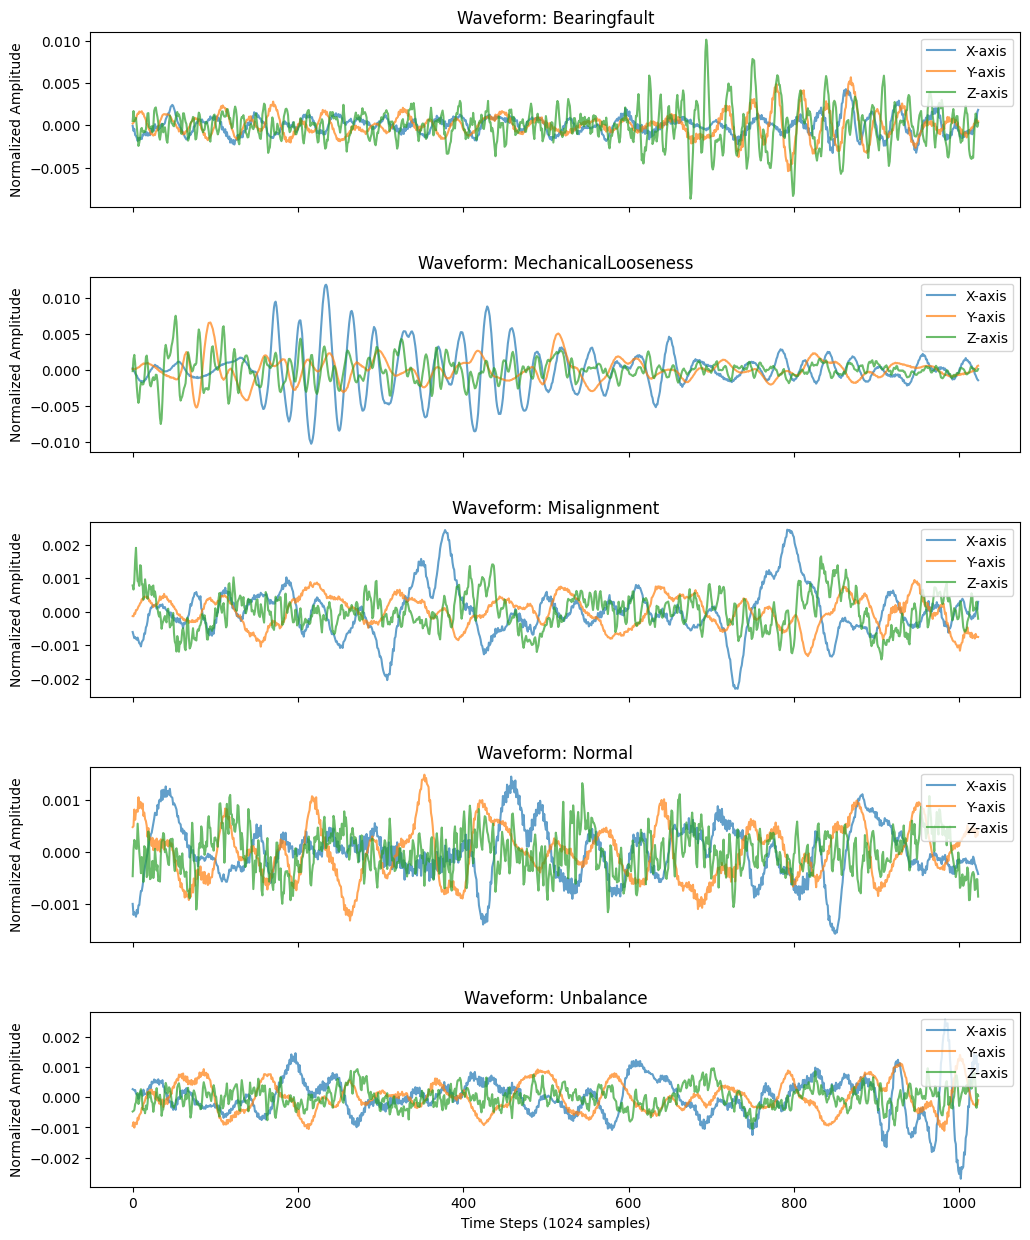

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique classes
unique_classes = np.unique(labels)

# Create a subplot for each class
fig, axes = plt.subplots(len(unique_classes), 1, figsize=(12, 15), sharex=True)
fig.subplots_adjust(hspace=0.4)

for i, cls in enumerate(unique_classes):
    # Find indices for the current class
    idx_list = np.where(labels == cls)[0]
    # Pick a random sample
    random_idx = np.random.choice(idx_list)

    # Extract the (3, 1024) tensor for this sample
    sample_tensor = tensors_normalized[random_idx]

    # Plot X, Y, and Z channels
    axes[i].plot(sample_tensor[0], label='X-axis', alpha=0.7)
    axes[i].plot(sample_tensor[1], label='Y-axis', alpha=0.7)
    axes[i].plot(sample_tensor[2], label='Z-axis', alpha=0.7)

    axes[i].set_title(f"Waveform: {cls}")
    axes[i].set_ylabel("Normalized Amplitude")
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel("Time Steps (1024 samples)")
plt.show()


### Phase 2, Step 2: Sanity-Check FFT
Even though the CNN will learn from the time-domain waveform, it's good practice to check the frequency domain. We use `np.fft.rfft` to compute the real FFT and plot the magnitudes. With a motor running at 2000 RPM (~33.3 Hz) and a 50 kHz sampling rate, we should see characteristic frequency peaks based on the fault.

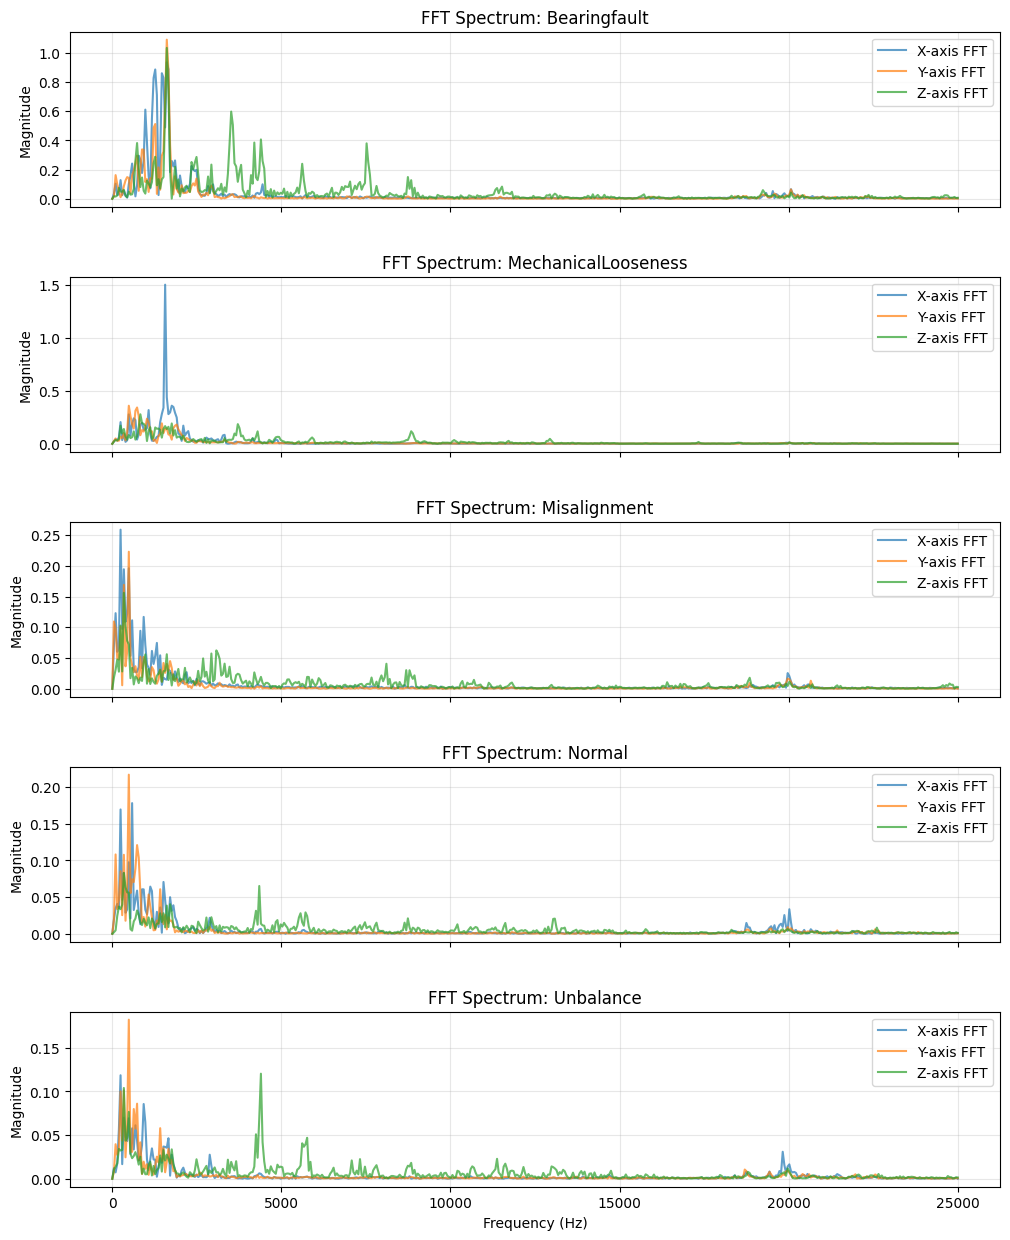

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters based on your plan
Fs = 50000.0  # 50 kHz sampling rate
N = 1024      # Number of samples per window

# Generate frequency axis (from 0 to Nyquist frequency, which is Fs/2)
freqs = np.fft.rfftfreq(N, d=1/Fs)

unique_classes = np.unique(labels)
fig, axes = plt.subplots(len(unique_classes), 1, figsize=(12, 15), sharex=True)
fig.subplots_adjust(hspace=0.4)

for i, cls in enumerate(unique_classes):
    # Pick a random sample from this class
    idx_list = np.where(labels == cls)[0]
    random_idx = np.random.choice(idx_list)

    # Extract X, Y, Z arrays for this sample
    sample_x = tensors_normalized[random_idx, 0, :]
    sample_y = tensors_normalized[random_idx, 1, :]
    sample_z = tensors_normalized[random_idx, 2, :]

    # Compute the FFT magnitude for each axis
    fft_x = np.abs(np.fft.rfft(sample_x))
    fft_y = np.abs(np.fft.rfft(sample_y))
    fft_z = np.abs(np.fft.rfft(sample_z))

    # Plot
    axes[i].plot(freqs, fft_x, label='X-axis FFT', alpha=0.7)
    axes[i].plot(freqs, fft_y, label='Y-axis FFT', alpha=0.7)
    axes[i].plot(freqs, fft_z, label='Z-axis FFT', alpha=0.7)

    axes[i].set_title(f"FFT Spectrum: {cls}")
    axes[i].set_ylabel("Magnitude")
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Frequency (Hz)")
plt.show()


### Phase 2, Step 3: Class Balance Check
We will count the aligned `(3, 1024)` windows for each state to see if our dataset is balanced or if we need to address any severe class imbalances before training the model.

Class Balance Check:
Bearingfault: 768 samples
MechanicalLooseness: 707 samples
Misalignment: 783 samples
Normal: 770 samples
Unbalance: 739 samples


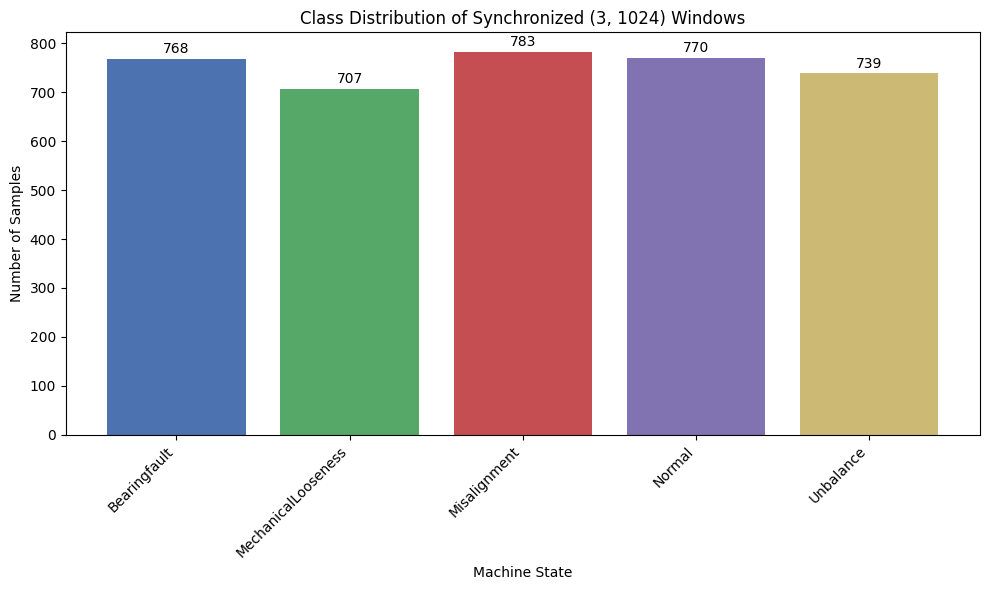

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Count the occurrences of each class
classes, counts = np.unique(labels, return_counts=True)

# Print the exact counts
print("Class Balance Check:")
for cls, count in zip(classes, counts):
    print(f"{cls}: {count} samples")

# Plot the distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, counts, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'])
plt.title("Class Distribution of Synchronized (3, 1024) Windows")
plt.xlabel("Machine State")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha='right')

# Add count labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Phase 3: The Train/Validation/Test Split
We split the dataset into three distinct vaults (70% Train, 15% Validation, 15% Test). We use `LabelEncoder` to translate string states into integers, and `stratify` to ensure an equal percentage of all five classes ends up in each split.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels to integers (0 to 4)
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

# Print the mapping so we know which number corresponds to which state
print("Label Mapping:")
for i, class_name in enumerate(encoder.classes_):
    print(f"{i} -> {class_name}")

# First split: 70% Train, 30% Temp (which will be split into Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    tensors_normalized,
    encoded_labels,
    test_size=0.30,
    random_state=42,
    stratify=encoded_labels
)

# Second split: 50% of Temp to Validation (15% of total), 50% of Temp to Test (15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\n--- Data Splits ---")
print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")


Label Mapping:
0 -> Bearingfault
1 -> MechanicalLooseness
2 -> Misalignment
3 -> Normal
4 -> Unbalance

--- Data Splits ---
Training set:   X=(2636, 3, 1024), y=(2636,)
Validation set: X=(565, 3, 1024), y=(565,)
Test set:       X=(566, 3, 1024), y=(566,)


### Phase 4: The 1D-CNN Architecture (Modeling)
We design a custom deep learning architecture tailored for our acoustic/vibration data. We transpose the data to `(samples, 1024, 3)` for Keras compatibility, apply Conv1D filters, pool them, and classify them through a dense Softmax head.

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import numpy as np

# Keras Conv1D expects inputs in the shape (batch_size, sequence_length, channels)
# Currently our shape is (samples, 3, 1024). We need to transpose it to (samples, 1024, 3)
X_train_k = np.transpose(X_train, (0, 2, 1))
X_val_k   = np.transpose(X_val, (0, 2, 1))
X_test_k  = np.transpose(X_test, (0, 2, 1))

print(f"Reshaped for Keras - Training set: {X_train_k.shape}\n")

# Define the 1D-CNN Architecture
model = Sequential([
    # Block 1: High-frequency filter (larger kernel size to catch rapid acoustic spikes)
    Conv1D(filters=32, kernel_size=16, activation='relu', input_shape=(1024, 3)),
    MaxPooling1D(pool_size=4),

    # Block 2: Mid-frequency filter
    Conv1D(filters=64, kernel_size=8, activation='relu'),
    MaxPooling1D(pool_size=4),

    # Block 3: Low-frequency filter (capturing slower patterns like unbalance)
    Conv1D(filters=128, kernel_size=4, activation='relu'),
    MaxPooling1D(pool_size=4),

    # Flatten spatial data to 1D vector
    Flatten(),

    # Fully connected dense layer for classification
    Dense(64, activation='relu'),
    Dropout(0.5),  # Prevent memorization/overfitting

    # Output layer: 5 nodes for 5 classes, using Softmax for probabilities
    Dense(5, activation='softmax')
])


Reshaped for Keras - Training set: (2636, 1024, 3)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Compile the model
# Since our labels are integers (0 to 4), we use 'sparse_categorical_crossentropy'
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1009, 32)       │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 252, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 245, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 58, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       114,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,989 (648.39 KB)

 Trainable params: 165,989 (648.39 KB)

 Non-trainable params: 0 (0.00 B)

### Phase 4, Step 2: Training the Model
We pass the training data through the network. We use `EarlyStopping` to halt training if the validation loss stops improving, ensuring we don't overfit.

Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.2462 - loss: 1.7695 - val_accuracy: 0.2000 - val_loss: 1.6510
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2781 - loss: 1.5867 - val_accuracy: 0.3876 - val_loss: 1.4414
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4131 - loss: 1.2550 - val_accuracy: 0.4212 - val_loss: 1.1050
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4165 - loss: 1.0757 - val_accuracy: 0.4513 - val_loss: 0.9855
Epoch 5/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4249 - loss: 0.9957 - val_accuracy: 0.5310 - val_loss: 0.9451
Epoch 6/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4382 - loss: 0.9735 - val_accuracy: 0.5310 - val_loss: 0.9435
Epoch 7/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4617 - loss: 0.9533 - val_accuracy: 0.4584 - val_loss: 0.9271
Epoch 8/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5004 - loss: 0.9184 - val_accuracy: 0.5735 - val_los

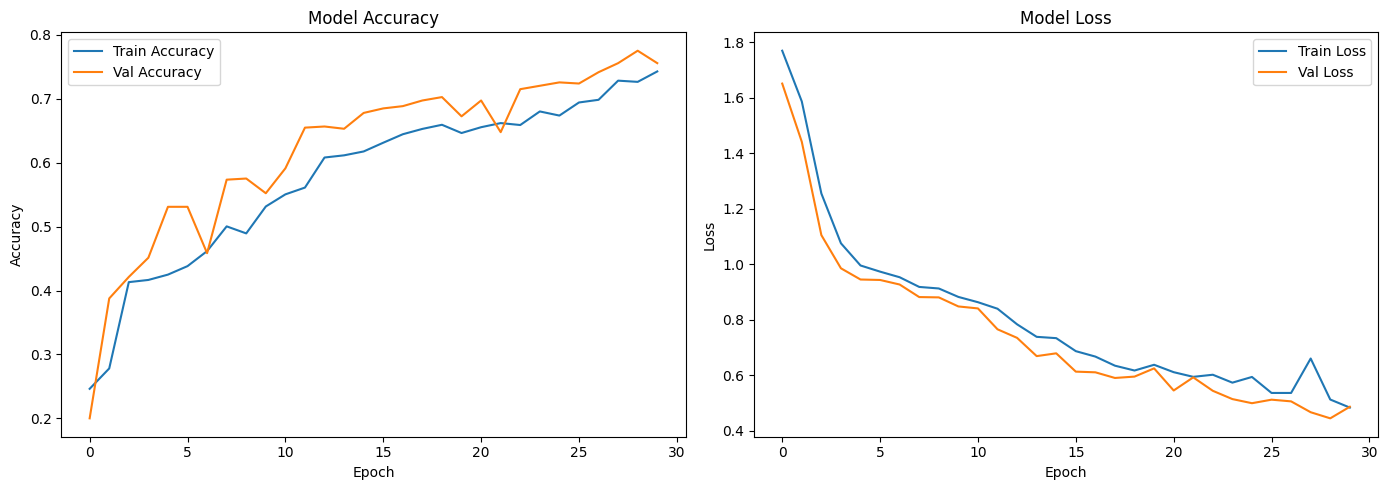

In [20]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,  # Wait 5 epochs before stopping if no improvement
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_k,
    y_train,
    epochs=30,  # Maximum number of epochs
    batch_size=32,
    validation_data=(X_val_k, y_val),
    callbacks=[early_stop]
)

# Plot the training and validation accuracy/loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


### Phase 4, Step 3: Model Evaluation
We evaluate the model's performance on the completely unseen Test set. A classification report is also generated to provide insights into precision, recall, and f1-score for each specific class.

In [21]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_k, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Get class predictions
y_pred_probs = model.predict(X_test_k)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Print the detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=encoder.classes_, zero_division=0))


Test Loss: 0.6750
Test Accuracy: 0.8092

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
Classification Report:
                     precision    recall  f1-score   support

       Bearingfault       0.94      0.88      0.91       116
MechanicalLooseness       0.88      0.93      0.90       106
       Misalignment       0.96      0.99      0.97       118
             Normal       0.61      0.74      0.67       115
          Unbalance       0.66      0.50      0.57       111

           accuracy                           0.81       566
          macro avg       0.81      0.81      0.80       566
       weighted avg       0.81      0.81      0.81       566



### Phase 5: Optimization (Frequency Domain)
Here we convert our `(samples, 1024, 3)` time-domain tensors into `(samples, 513, 3)` frequency-domain tensors using `np.fft.rfft`.

In [22]:
import numpy as np

# Compute the magnitude of the Real FFT along the sequence axis (axis=1)
X_train_fft = np.abs(np.fft.rfft(X_train_k, axis=1))
X_val_fft   = np.abs(np.fft.rfft(X_val_k, axis=1))
X_test_fft  = np.abs(np.fft.rfft(X_test_k, axis=1))

# FFT magnitudes can have massive spikes. We use log1p (log(1+x)) to compress the scale
X_train_fft = np.log1p(X_train_fft)
X_val_fft   = np.log1p(X_val_fft)
X_test_fft  = np.log1p(X_test_fft)

print(f"Original Time-Domain Shape: {X_train_k.shape}")
print(f"New Frequency-Domain Shape: {X_train_fft.shape}")


Original Time-Domain Shape: (2636, 1024, 3)
New Frequency-Domain Shape: (2636, 513, 3)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

# The number of frequency bins is now 513
freq_bins = X_train_fft.shape[1]
channels = X_train_fft.shape[2]

fft_model = Sequential([
    # Block 1
    Conv1D(filters=32, kernel_size=8, activation='relu', input_shape=(freq_bins, channels)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Block 2
    Conv1D(filters=64, kernel_size=4, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Block 3
    Conv1D(filters=128, kernel_size=4, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

fft_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fft_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 506, 32)        │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 506, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 253, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 250, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 250, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 122, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 122, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 61, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7808)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       499,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,949 (2.07 MB)

 Trainable params: 542,501 (2.07 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.7693 - loss: 0.8553 - val_accuracy: 0.2071 - val_loss: 2.5484
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8581 - loss: 0.3730 - val_accuracy: 0.2053 - val_loss: 2.9534
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8733 - loss: 0.3059 - val_accuracy: 0.1982 - val_loss: 3.1998
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8961 - loss: 0.2533 - val_accuracy: 0.4000 - val_loss: 2.8044
Epoch 5/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9177 - loss: 0.1947 - val_accuracy: 0.3681 - val_loss: 1.9364
Epoch 6/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9340 - loss: 0.1535 - val_accuracy: 0.2053 - val_loss: 4.0850
Epoch 7/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9329 - loss: 0.1619 - val_accuracy: 0.6938 - val_loss: 2.3517
Epoch 8/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9363 - loss: 0.1698 - val_accuracy: 0.9540 - val_los

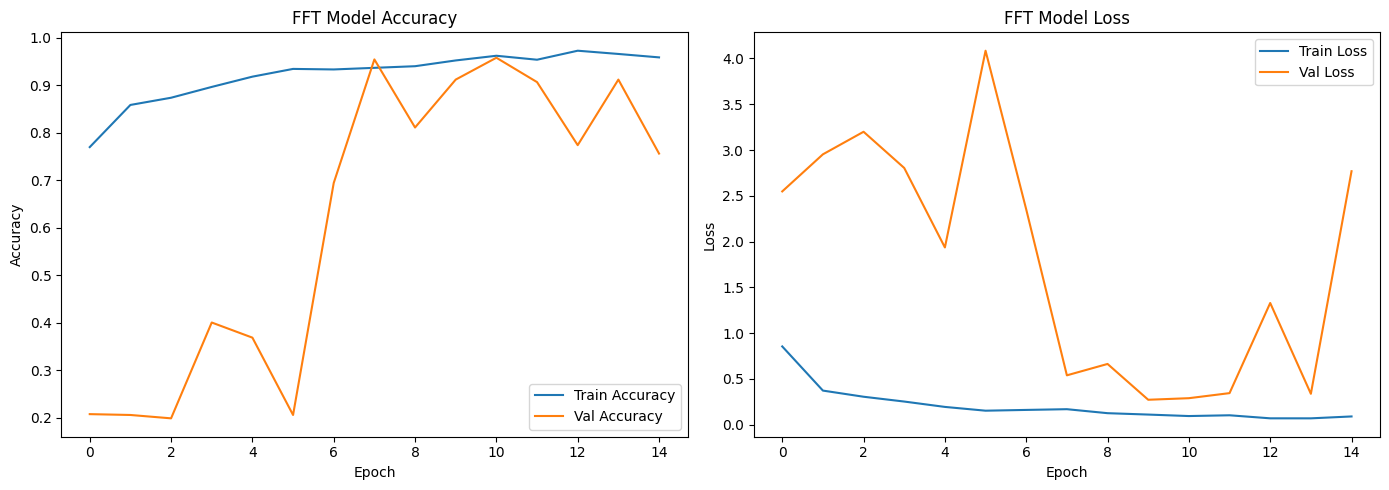

In [24]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Early stopping
early_stop_fft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_fft = fft_model.fit(
    X_train_fft, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_fft, y_val),
    callbacks=[early_stop_fft]
)

# Plot the training and validation accuracy/loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_fft.history['accuracy'], label='Train Accuracy')
ax1.plot(history_fft.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('FFT Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_fft.history['loss'], label='Train Loss')
ax2.plot(history_fft.history['val_loss'], label='Val Loss')
ax2.set_title('FFT Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


### Phase 5, Step 2: Evaluating the Optimized Model
Let's see if our frequency-domain approach solved the 'model collapse' issue. We will evaluate the `fft_model` on our unseen test dataset and generate a new Classification Report.

In [25]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate the FFT model
fft_test_loss, fft_test_accuracy = fft_model.evaluate(X_test_fft, y_test, verbose=0)
print(f"FFT Model Test Loss: {fft_test_loss:.4f}")
print(f"FFT Model Test Accuracy: {fft_test_accuracy:.4f}\n")

# Get class predictions for the FFT model
y_pred_probs_fft = fft_model.predict(X_test_fft)
y_pred_classes_fft = np.argmax(y_pred_probs_fft, axis=1)

# Print the detailed classification report
print("FFT Model Classification Report:")
print(classification_report(y_test, y_pred_classes_fft, target_names=encoder.classes_, zero_division=0))


FFT Model Test Loss: 0.2085
FFT Model Test Accuracy: 0.9205

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
FFT Model Classification Report:
                     precision    recall  f1-score   support

       Bearingfault       1.00      1.00      1.00       116
MechanicalLooseness       1.00      0.98      0.99       106
       Misalignment       1.00      1.00      1.00       118
             Normal       0.96      0.63      0.76       115
          Unbalance       0.72      0.99      0.84       111

           accuracy                           0.92       566
          macro avg       0.94      0.92      0.92       566
       weighted avg       0.94      0.92      0.92       566



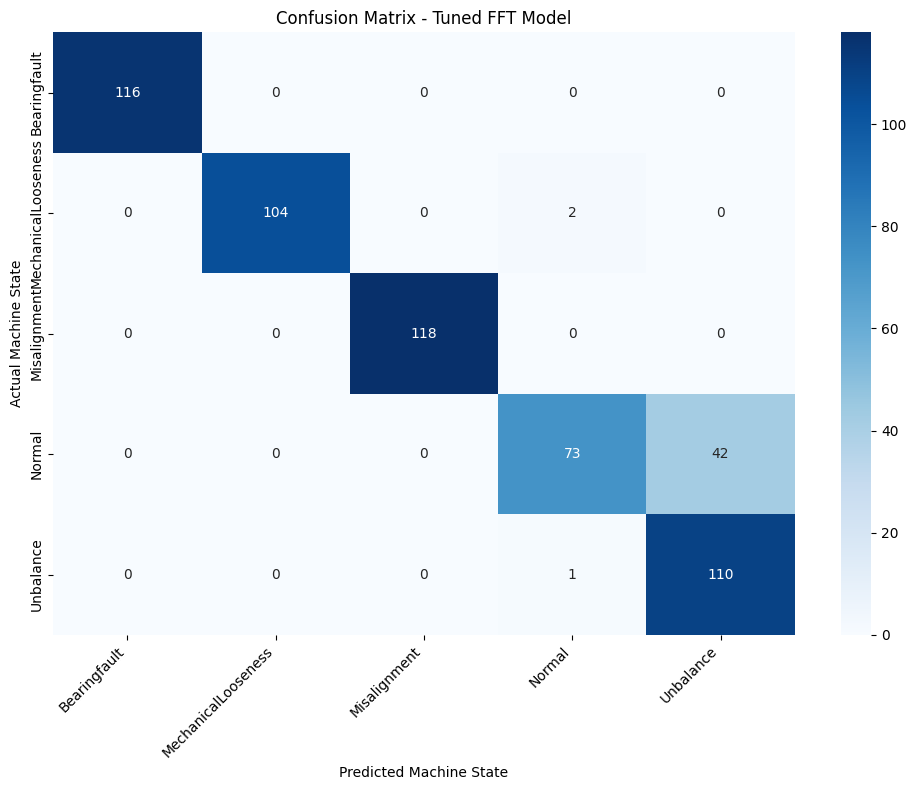

In [32]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes_fft)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title('Confusion Matrix - Tuned FFT Model')
plt.ylabel('Actual Machine State')
plt.xlabel('Predicted Machine State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Phase 5 Alternative: Advanced 1D-CNN Architecture
Instead of manual feature extraction, we upgrade our neural network. We add `BatchNormalization` to stabilize learning, use `padding='same'` to preserve spatial dimensions, replace `Flatten` with `GlobalAveragePooling1D` to dramatically reduce overfitting, and use a slower learning rate.

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

tuned_model = Sequential([
    # Block 1: Initial feature extraction
    Conv1D(filters=64, kernel_size=7, padding='same', input_shape=(1024, 3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Block 2: Deeper features
    Conv1D(filters=128, kernel_size=5, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Block 3: High-level representation
    Conv1D(filters=256, kernel_size=3, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Global Average Pooling replaces Flatten to reduce parameter count and overfitting
    GlobalAveragePooling1D(),

    # Classification head
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# Compile with a slightly lower learning rate to avoid jumping into local minima (model collapse)
optimizer = Adam(learning_rate=0.0005)
tuned_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tuned_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 1024, 64)       │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 512, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 256, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,389 (689.02 KB)

 Trainable params: 175,493 (685.52 KB)

 Non-trainable params: 896 (3.50 KB)

Training Tuned 1D-CNN on Time-Domain Data...
Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.4848 - loss: 1.1285 - val_accuracy: 0.2088 - val_loss: 1.6260
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6461 - loss: 0.8086 - val_accuracy: 0.2071 - val_loss: 1.6259
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6855 - loss: 0.6839 - val_accuracy: 0.2018 - val_loss: 1.8371
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6908 - loss: 0.6516 - val_accuracy: 0.2018 - val_loss: 2.8151
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7204 - loss: 0.6022 - val_accuracy: 0.2018 - val_loss: 4.6514
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7269 - loss: 0.5888 - val_accuracy: 0.2018 - val_loss: 7.2647
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7223 - loss: 0.5902 - val_accuracy: 0.2000 - val_loss: 10.2501
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.74

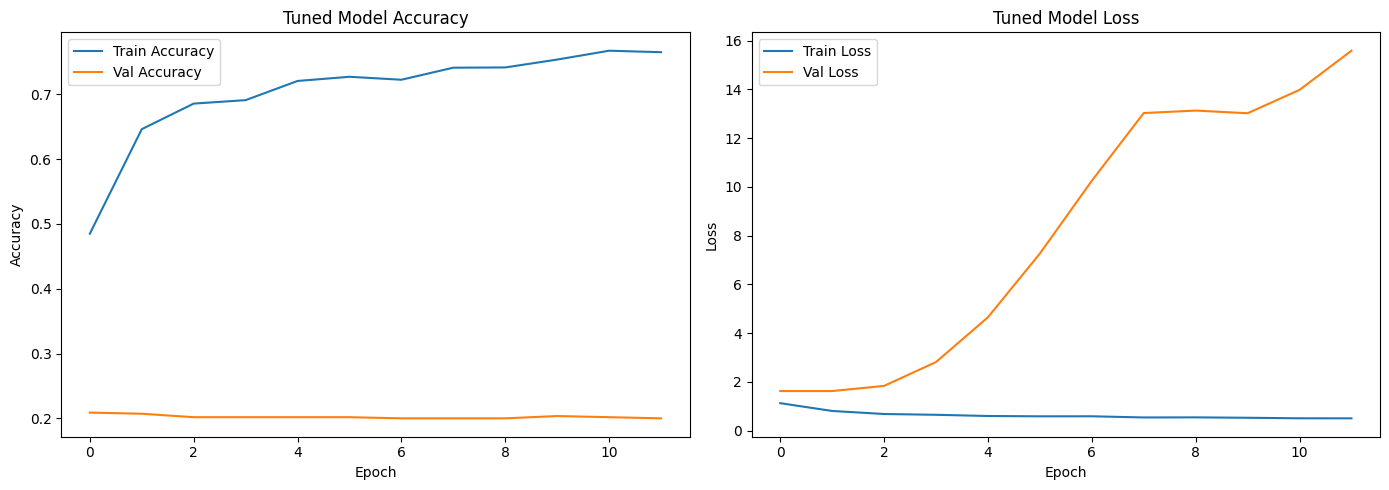

In [27]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Slightly longer patience since a lower learning rate takes more epochs to converge
early_stop_tuned = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Tuned 1D-CNN on Time-Domain Data...")
history_tuned = tuned_model.fit(
    X_train_k, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_k, y_val),
    callbacks=[early_stop_tuned]
)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_tuned.history['accuracy'], label='Train Accuracy')
ax1.plot(history_tuned.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Tuned Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_tuned.history['loss'], label='Train Loss')
ax2.plot(history_tuned.history['val_loss'], label='Val Loss')
ax2.set_title('Tuned Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


### Phase 5 Alternative: Tuned 1D-CNN on FFT Data
Combining the advanced network architecture (Batch Normalization, Global Average Pooling) with the frequency-domain (FFT) data to prevent overfitting while extracting clean frequency signatures.

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

# The number of frequency bins is 513
freq_bins = X_train_fft.shape[1]
channels = X_train_fft.shape[2]

tuned_fft_model = Sequential([
    # Block 1
    Conv1D(filters=64, kernel_size=7, padding='same', input_shape=(freq_bins, channels)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Block 2
    Conv1D(filters=128, kernel_size=5, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Block 3
    Conv1D(filters=256, kernel_size=3, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),

    # Global Average Pooling to reduce dimensions and prevent overfitting
    GlobalAveragePooling1D(),

    # Classification head
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# Compile with lower learning rate
optimizer = Adam(learning_rate=0.0005)
tuned_fft_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tuned_fft_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 513, 64)        │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 513, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 513, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 128, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,389 (689.02 KB)

 Trainable params: 175,493 (685.52 KB)

 Non-trainable params: 896 (3.50 KB)

Training Tuned 1D-CNN on FFT Data...
Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.4366 - loss: 1.2341 - val_accuracy: 0.2035 - val_loss: 1.6035
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6168 - loss: 0.9220 - val_accuracy: 0.2018 - val_loss: 1.7539
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7200 - loss: 0.7122 - val_accuracy: 0.2000 - val_loss: 2.4742
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7504 - loss: 0.5859 - val_accuracy: 0.2000 - val_loss: 3.3855
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7640 - loss: 0.5533 - val_accuracy: 0.2071 - val_loss: 3.9587
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7640 - loss: 0.5035 - val_accuracy: 0.2035 - val_loss: 4.4987
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7750 - loss: 0.4802 - val_accuracy: 0.2018 - val_loss: 4.0302
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7788 - loss: 0.

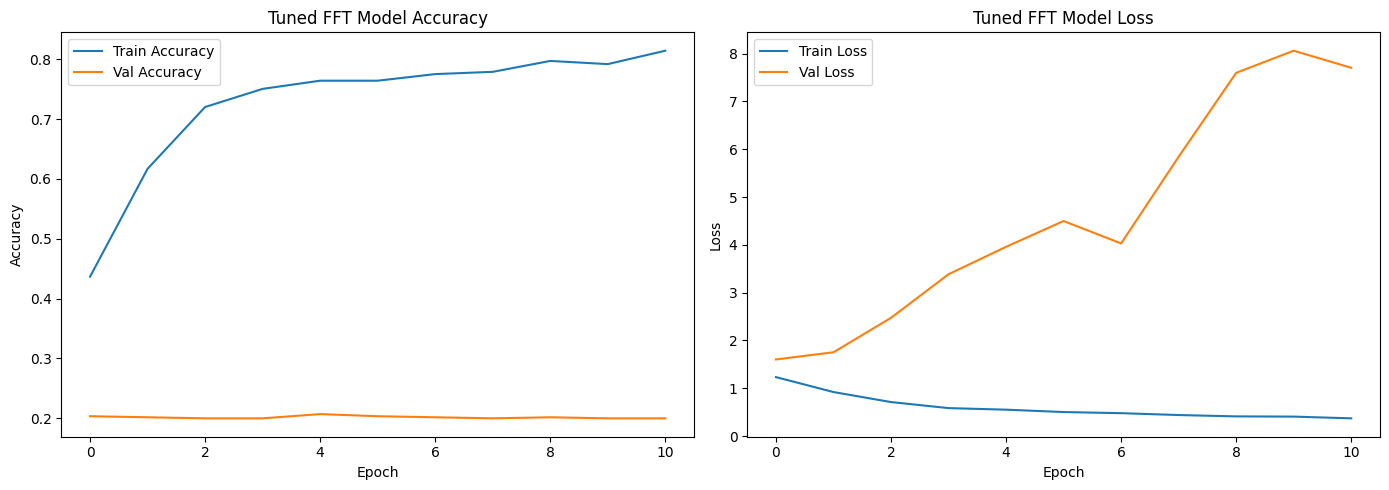

In [29]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

early_stop_tuned_fft = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Tuned 1D-CNN on FFT Data...")
history_tuned_fft = tuned_fft_model.fit(
    X_train_fft, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_fft, y_val),
    callbacks=[early_stop_tuned_fft]
)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_tuned_fft.history['accuracy'], label='Train Accuracy')
ax1.plot(history_tuned_fft.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Tuned FFT Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_tuned_fft.history['loss'], label='Train Loss')
ax2.plot(history_tuned_fft.history['val_loss'], label='Val Loss')
ax2.set_title('Tuned FFT Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


### Phase 5 Alternative: Evaluate the Tuned FFT Model
Let's test our advanced 1D-CNN architecture trained on frequency-domain data against the unseen test set.

In [30]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate the Tuned FFT model
tuned_fft_test_loss, tuned_fft_test_accuracy = tuned_fft_model.evaluate(X_test_fft, y_test, verbose=0)
print(f"Tuned FFT Model Test Loss: {tuned_fft_test_loss:.4f}")
print(f"Tuned FFT Model Test Accuracy: {tuned_fft_test_accuracy:.4f}\n")

# Get class predictions
y_pred_probs_tuned_fft = tuned_fft_model.predict(X_test_fft)
y_pred_classes_tuned_fft = np.argmax(y_pred_probs_tuned_fft, axis=1)

# Print the detailed classification report
print("Tuned FFT Model Classification Report:")
print(classification_report(y_test, y_pred_classes_tuned_fft, target_names=encoder.classes_, zero_division=0))


Tuned FFT Model Test Loss: 1.5971
Tuned FFT Model Test Accuracy: 0.2120

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step
Tuned FFT Model Classification Report:
                     precision    recall  f1-score   support

       Bearingfault       0.00      0.00      0.00       116
MechanicalLooseness       0.50      0.01      0.02       106
       Misalignment       0.21      1.00      0.35       118
             Normal       0.50      0.01      0.02       115
          Unbalance       0.00      0.00      0.00       111

           accuracy                           0.21       566
          macro avg       0.24      0.20      0.08       566
       weighted avg       0.24      0.21      0.08       566



### Phase 6: Error Analysis (Confusion Matrix)
Let's visualize exactly where our Tuned FFT model is making mistakes, specifically to investigate why the 'Normal state' recall is so low.

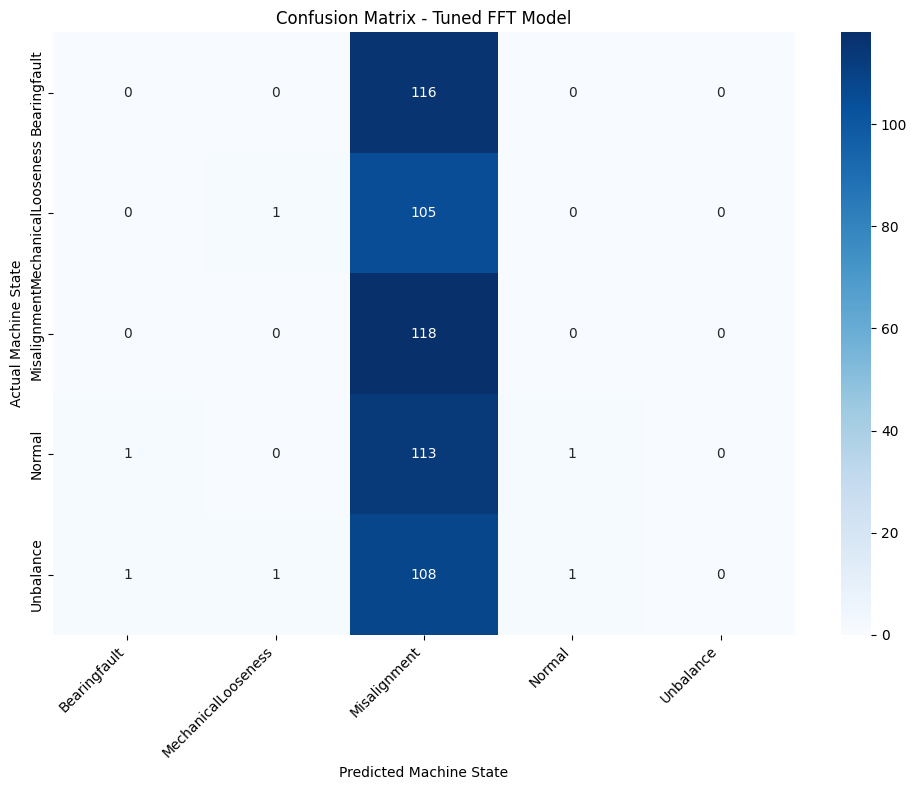

In [31]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes_tuned_fft)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title('Confusion Matrix - Tuned FFT Model')
plt.ylabel('Actual Machine State')
plt.xlabel('Predicted Machine State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
